# Домен: Енергетика (Споживання електроенергії, Франція)
Цільова змінна: `actual_load` (МВт). Горизонт прогнозу: 24 години (day-ahead).

## 1. Налаштування середовища та завантаження даних

In [44]:
# Тихе встановлення необхідних бібліотек для отримання даних та статистичного моделювання
!pip install -q entsoe-py pmdarima statsmodels

# Імпорт та фіксація версій ключових інструментів для звіту курсової роботи
import entsoe
import pmdarima
import tensorflow as tf
import xgboost as xgb
import sklearn
import statsmodels

print("Середовище успішно налаштовано. Версії бібліотек:")
print(f"- ENTSO-E: {entsoe.__version__}")
print(f"- Pmdarima: {pmdarima.__version__}")
print(f"- Statsmodels: {statsmodels.__version__}")
print(f"- TensorFlow: {tf.__version__}")
print(f"- XGBoost: {xgb.__version__}")
print(f"- Scikit-Learn: {sklearn.__version__}")

Середовище успішно налаштовано. Версії бібліотек:
- ENTSO-E: 0.7.11
- Pmdarima: 2.1.1
- Statsmodels: 0.14.6
- TensorFlow: 2.19.0
- XGBoost: 3.2.0
- Scikit-Learn: 1.6.1


In [45]:
import pandas as pd
from kaggle_secrets import UserSecretsClient
from entsoe import EntsoePandasClient
import pytz

# 1. Отримання токену з Kaggle Secrets
user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("ENTSOE_TOKEN")

# 2. Ініціалізація клієнта
client = EntsoePandasClient(api_key=api_key)

# 3. Налаштування параметрів запиту
country_code = 'FR' 
timezone = 'Europe/Paris'

start = pd.Timestamp('2018-01-01', tz=timezone)
end = pd.Timestamp('2021-01-01', tz=timezone)

print("Завантаження даних з ENTSO-E API. Це може зайняти хвилину...")

load_series = client.query_load(country_code, start=start, end=end)

# 4. Очищення даних
if isinstance(load_series, pd.Series):
    df = load_series.to_frame(name='actual_load')
else:
    df = load_series.copy()
    df = df.iloc[:, [0]]
    df.columns = ['actual_load']

# 'h' замість 'H' — актуальний аліас у pandas >= 2.2
df = df.resample('h').mean()

df['actual_load'] = df['actual_load'].interpolate(method='linear')

# 5. Feature Engineering
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
df['month'] = df.index.month

print("Дані успішно оброблено. Розмір датасету:", df.shape)
print("\nПерші 5 рядків:")
print(df.head())

Завантаження даних з ENTSO-E API. Це може зайняти хвилину...
Дані успішно оброблено. Розмір датасету: (26304, 5)

Перші 5 рядків:
                           actual_load  hour  dayofweek  is_weekend  month
2018-01-01 00:00:00+01:00      57638.0     0          0           0      1
2018-01-01 01:00:00+01:00      56036.0     1          0           0      1
2018-01-01 02:00:00+01:00      54494.0     2          0           0      1
2018-01-01 03:00:00+01:00      51574.0     3          0           0      1
2018-01-01 04:00:00+01:00      49370.0     4          0           0      1


## 2. Розділення даних та підготовка

In [46]:
# 1. Ізоляція стабільного періоду (тільки 2018 - 2019 роки)
# Відсікаємо всі дані, починаючи з 2020-01-01
stable_df = df[df.index < '2020-01-01'].copy()

print(f"Діапазон стабільних даних: з {stable_df.index.min().date()} по {stable_df.index.max().date()}")

# 2. Хронологічне розбиття на Train / Test (80% / 20%) ВИКЛЮЧНО стабільних даних
split_index = int(len(stable_df) * 0.8)

train_df = stable_df.iloc[:split_index].copy()
test_df = stable_df.iloc[split_index:].copy()

print(f"Розмір Train: {len(train_df)} годин")
print(f"Розмір Test:  {len(test_df)} годин\n")

# Перевірка меж дат для впевненості у відсутності витоку
print(f"Остання дата Train: {train_df.index.max()}")
print(f"Перша дата Test:    {test_df.index.min()}")

Діапазон стабільних даних: з 2018-01-01 по 2019-12-31
Розмір Train: 14016 годин
Розмір Test:  3504 годин

Остання дата Train: 2019-08-08 00:00:00+02:00
Перша дата Test:    2019-08-08 01:00:00+02:00


In [47]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

feature_cols = ['actual_load', 'hour', 'dayofweek', 'is_weekend', 'month']
target_col = 'actual_load'
target_idx = feature_cols.index(target_col)

train_scaled_df = train_df.copy()
test_scaled_df = test_df.copy()

train_scaled_df[feature_cols] = scaler_X.fit_transform(train_df[feature_cols])
test_scaled_df[feature_cols] = scaler_X.transform(test_df[feature_cols])
scaler_y.fit(train_df[[target_col]])

def create_sliding_window_multistep(data_array, window_size, horizon, target_idx):
    X, y = [], []
    for i in range(len(data_array) - window_size - horizon + 1):
        X.append(data_array[i : i + window_size, :])
        y.append(data_array[i + window_size : i + window_size + horizon, target_idx])
    return np.array(X), np.array(y)

window_size = 168
horizon = 24

X_train_3d, y_train_24h = create_sliding_window_multistep(train_scaled_df.values, window_size, horizon, target_idx)
X_test_3d, y_test_24h = create_sliding_window_multistep(test_scaled_df.values, window_size, horizon, target_idx)

X_train_2d = X_train_3d.reshape((X_train_3d.shape[0], -1))
X_test_2d = X_test_3d.reshape((X_test_3d.shape[0], -1))

# Розмасштовуємо y_test одразу тут — це частина підготовки даних
y_test_true_unscaled = scaler_y.inverse_transform(y_test_24h)

print("Форма даних для Deep Learning:")
print(f"X_train_3d: {X_train_3d.shape}  -> (Зразки, Вікно історії, Ознаки)")
print(f"X_test_3d:  {X_test_3d.shape}")
print(f"y_train_24h:{y_train_24h.shape}  -> (Зразки, Горизонт прогнозу)")
print(f"y_test_24h: {y_test_24h.shape}")
print(f"y_test_true_unscaled: {y_test_true_unscaled.shape}\n")

print("Форма даних для Classical ML (XGBoost):")
print(f"X_train_2d: {X_train_2d.shape}  -> (Зразки, Сплющені ознаки: {window_size}*{len(feature_cols)})")
print(f"X_test_2d:  {X_test_2d.shape}")

Форма даних для Deep Learning:
X_train_3d: (13825, 168, 5)  -> (Зразки, Вікно історії, Ознаки)
X_test_3d:  (3313, 168, 5)
y_train_24h:(13825, 24)  -> (Зразки, Горизонт прогнозу)
y_test_24h: (3313, 24)
y_test_true_unscaled: (3313, 24)

Форма даних для Classical ML (XGBoost):
X_train_2d: (13825, 840)  -> (Зразки, Сплющені ознаки: 168*5)
X_test_2d:  (3313, 840)


## 3. Базові моделі (Baselines)

In [48]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Увага: ця клітинка має виконуватись після клітинок з
# X_test_3d, scaler_y та y_test_true_unscaled

print("Чесний розрахунок базових моделей на ВСІХ вікнах тестової вибірки...")

# Цільова змінна для всіх вікон (вже розмасштабована)
actual_test_true = y_test_true_unscaled

# 1. Daily Seasonal Naive (t-24)
daily_pred_scaled = X_test_3d[:, -24:, 0]
daily_pred_unscaled = scaler_y.inverse_transform(daily_pred_scaled)

# 2. Weekly Seasonal Naive (t-168)
weekly_pred_scaled = X_test_3d[:, :24, 0]
weekly_pred_unscaled = scaler_y.inverse_transform(weekly_pred_scaled)

# Функція для чесного розрахунку (із захистом від ділення на нуль)
def calc_fair_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    print(f"--- Усереднений {model_name} (на всіх вікнах) ---")
    print(f"MAE:  {mae:.2f} МВт")
    print(f"RMSE: {rmse:.2f} МВт")
    print(f"MAPE: {mape:.2f}%\n")

calc_fair_metrics(actual_test_true, daily_pred_unscaled, "Daily Seasonal Naïve (t-24)")
calc_fair_metrics(actual_test_true, weekly_pred_unscaled, "Weekly Seasonal Naïve (t-168)")

Чесний розрахунок базових моделей на ВСІХ вікнах тестової вибірки...
--- Усереднений Daily Seasonal Naïve (t-24) (на всіх вікнах) ---
MAE:  2871.09 МВт
RMSE: 4320.54 МВт
MAPE: 5.53%

--- Усереднений Weekly Seasonal Naïve (t-168) (на всіх вікнах) ---
MAE:  3510.33 МВт
RMSE: 5015.08 МВт
MAPE: 6.23%



## 4. Етап 1: Моделі з базовими конфігураціями

### 4.1. MLP (Багатошаровий перцептрон)

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Створення моделі Багатошарового перцептрона (MLP)
def build_mlp_model(input_dim, output_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'),
        Dropout(0.2),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(output_dim)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

input_dimension = X_train_2d.shape[1]  # 840
output_dimension = horizon              # 24

mlp_model = build_mlp_model(input_dimension, output_dimension)
mlp_model.summary()

# early_stopping НЕ створюємо тут глобально.
# Кожна модель створює власний екземпляр безпосередньо перед fit,
# щоб уникнути перенесення внутрішнього стану між моделями.
def make_early_stopping():
    return EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 256)            │       215,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 251,288 (981.59 KB)

 Trainable params: 251,288 (981.59 KB)

 Non-trainable params: 0 (0.00 B)

Початок навчання моделі MLP...
Epoch 1/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0625 - mae: 0.1681 - val_loss: 0.0052 - val_mae: 0.0571
Epoch 2/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0111 - mae: 0.0812 - val_loss: 0.0033 - val_mae: 0.0464
Epoch 3/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0082 - mae: 0.0698 - val_loss: 0.0027 - val_mae: 0.0421
Epoch 4/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0066 - mae: 0.0629 - val_loss: 0.0023 - val_mae: 0.0384
Epoch 5/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0057 - mae: 0.0584 - val_loss: 0.0018 - val_mae: 0.0349
Epoch 6/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0054 - mae: 0.0567 - val_loss: 0.0027 - val_mae: 0.0418
Epoch 7/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0052 - mae: 0.0557 - val_loss: 0.0018 - val_mae: 0.0342
Epoch 8/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0047 - mae: 0.0531 - val_loss: 0.0016 - val_mae: 0.0325
Epoch 9/100
195/

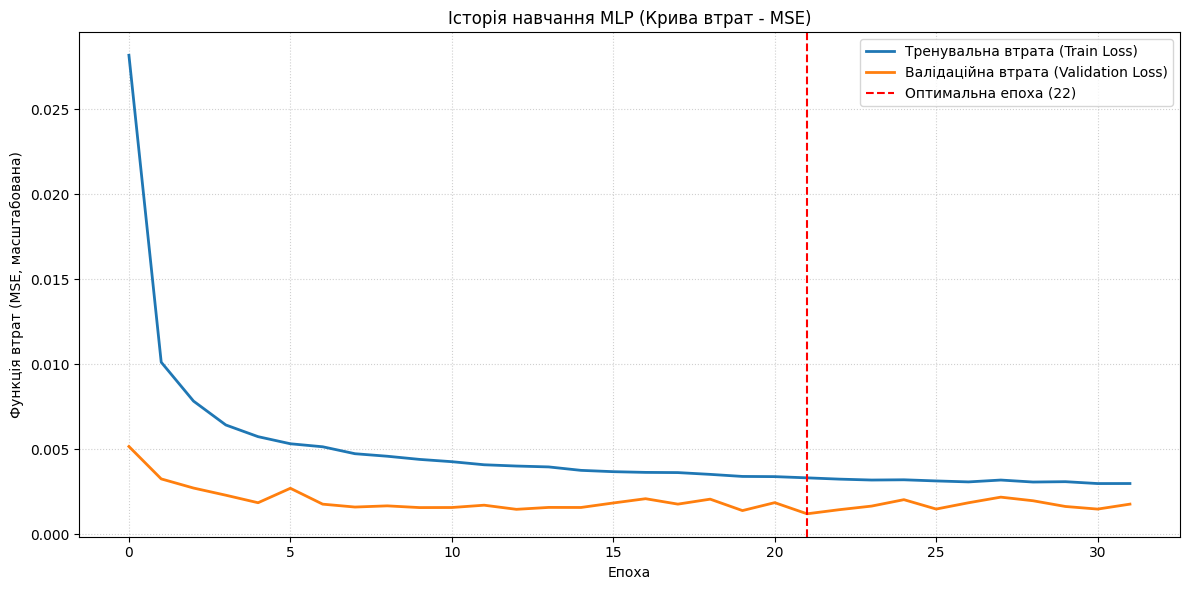

In [50]:
import matplotlib.pyplot as plt

epochs = 100
batch_size = 64

print("Початок навчання моделі MLP...")

# Створюємо власний екземпляр early stopping для MLP
es_mlp = make_early_stopping()

history = mlp_model.fit(
    X_train_2d,
    y_train_24h,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[es_mlp],
    verbose=1
)

print(f"\nНавчання зупинено. Оптимальні ваги відновлено.")
print(f"Кількість пройдених епох: {len(history.history['loss'])}")

# Візуалізація кривої втрат
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Тренувальна втрата (Train Loss)', linewidth=2)
plt.plot(history.history['val_loss'], label='Валідаційна втрата (Validation Loss)', linewidth=2)

best_epoch = es_mlp.best_epoch
if best_epoch is not None:
    plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Оптимальна епоха ({best_epoch+1})')

plt.title('Історія навчання MLP (Крива втрат - MSE)')
plt.xlabel('Епоха')
plt.ylabel('Функція втрат (MSE, масштабована)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Генерація прогнозів на тестовій вибірці...
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- Результати MLP (на горизонті 24 години) ---
MAE:  2191.69 МВт
RMSE: 2938.21 МВт
MAPE: 4.10%


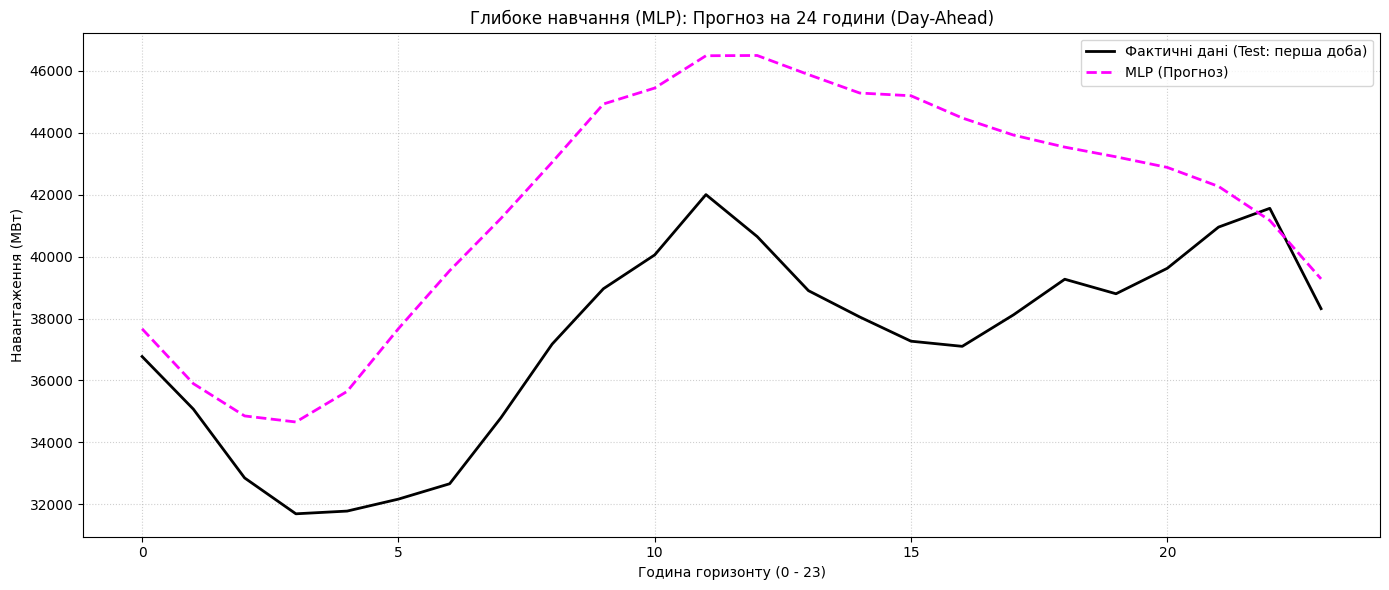

In [51]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

print("Генерація прогнозів на тестовій вибірці...")

# 1. Прогнози MLP
mlp_pred_scaled = mlp_model.predict(X_test_2d)

# 2. Зворотне перетворення у Мегавати
# y_test_true_unscaled вже визначено в Cell 6
mlp_pred_unscaled = scaler_y.inverse_transform(mlp_pred_scaled)

# 3. Розрахунок метрик
mae_mlp = mean_absolute_error(y_test_true_unscaled, mlp_pred_unscaled)
rmse_mlp = np.sqrt(mean_squared_error(y_test_true_unscaled, mlp_pred_unscaled))

mask = y_test_true_unscaled != 0
mape_mlp = np.mean(np.abs(
    (y_test_true_unscaled[mask] - mlp_pred_unscaled[mask]) / y_test_true_unscaled[mask]
)) * 100

print("\n--- Результати MLP (на горизонті 24 години) ---")
print(f"MAE:  {mae_mlp:.2f} МВт")
print(f"RMSE: {rmse_mlp:.2f} МВт")
print(f"MAPE: {mape_mlp:.2f}%")

# 4. Візуалізація першої доби
first_24h_true = y_test_true_unscaled[0]
first_24h_pred = mlp_pred_unscaled[0]

plt.figure(figsize=(14, 6))
plt.plot(range(24), first_24h_true, label='Фактичні дані (Test: перша доба)', color='black', linewidth=2)
plt.plot(range(24), first_24h_pred, label='MLP (Прогноз)', color='magenta', linestyle='--', linewidth=2)

plt.title('Глибоке навчання (MLP): Прогноз на 24 години (Day-Ahead)')
plt.xlabel('Година горизонту (0 - 23)')
plt.ylabel('Навантаження (МВт)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### 4.2. 1D-CNN (Згорткова нейромережа)

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 145, 64)        │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 72, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 61, 32)         │        24,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       123,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,456 (618.97 KB)

 Trainable params: 158,456 (618.97 KB)

 Non-trainable params: 0 (0.00 B)

None

Початок навчання моделі 1D-CNN...
Epoch 1/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0295 - mae: 0.1223 - val_loss: 0.0023 - val_mae: 0.0390
Epoch 2/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0065 - mae: 0.0614 - val_loss: 0.0015 - val_mae: 0.0309
Epoch 3/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0046 - mae: 0.0511 - val_loss: 0.0017 - val_mae: 0.0332
Epoch 4/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0039 - mae: 0.0472 - val_loss: 9.4711e-04 - val_mae: 0.0242
Epoch 5/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0033 - mae: 0.0438 - val_loss: 0.0011 - val_mae: 0.0257
Epoch 6/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0033 - mae: 0.0435 - val_loss: 0.0012 - val_mae: 0.0273
Epoch 7/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0027 - mae: 0.0393 - val_loss: 9.3916e-04 - val_mae: 0.0240
Epoch 8/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0026 - mae: 0.0387 - val_loss: 9.6345e-04 - val_mae: 0.

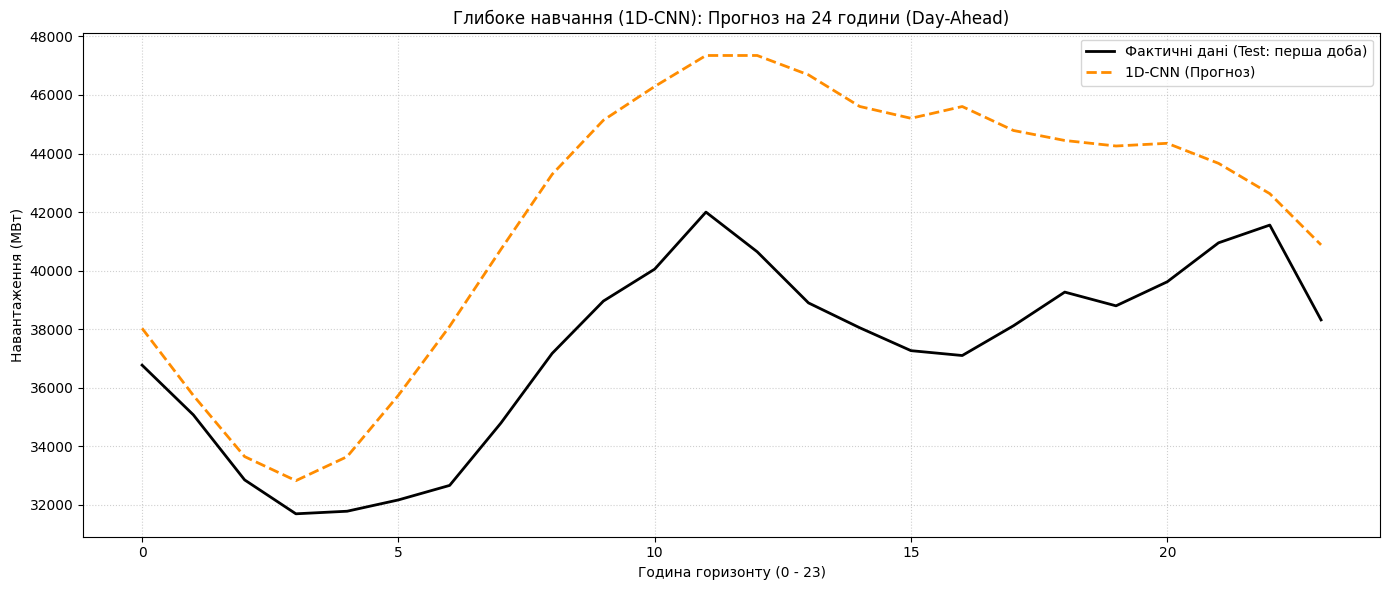

In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1. Архітектура 1D-CNN
def build_cnn_model(timesteps, features, output_dim):
    model = Sequential([
        Input(shape=(timesteps, features)),
        Conv1D(filters=64, kernel_size=24, activation='relu'),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=32, kernel_size=12, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(output_dim)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

timesteps = X_train_3d.shape[1]
features = X_train_3d.shape[2]
output_dimension = horizon

cnn_model = build_cnn_model(timesteps, features, output_dimension)
print(cnn_model.summary())

# 2. Навчання 1D-CNN з власним екземпляром early stopping
print("\nПочаток навчання моделі 1D-CNN...")
es_cnn = make_early_stopping()

history_cnn = cnn_model.fit(
    X_train_3d,
    y_train_24h,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=[es_cnn],
    verbose=1
)

# 3. Оцінка моделі
print("\nГенерація прогнозів 1D-CNN на тестовій вибірці...")
cnn_pred_scaled = cnn_model.predict(X_test_3d)
cnn_pred_unscaled = scaler_y.inverse_transform(cnn_pred_scaled)

mae_cnn = mean_absolute_error(y_test_true_unscaled, cnn_pred_unscaled)
rmse_cnn = np.sqrt(mean_squared_error(y_test_true_unscaled, cnn_pred_unscaled))

mask = y_test_true_unscaled != 0
mape_cnn = np.mean(np.abs(
    (y_test_true_unscaled[mask] - cnn_pred_unscaled[mask]) / y_test_true_unscaled[mask]
)) * 100

print("\n--- Результати 1D-CNN (на горизонті 24 години) ---")
print(f"MAE:  {mae_cnn:.2f} МВт")
print(f"RMSE: {rmse_cnn:.2f} МВт")
print(f"MAPE: {mape_cnn:.2f}%")

# 4. Візуалізація першої доби
first_24h_true_cnn = y_test_true_unscaled[0]
first_24h_pred_cnn = cnn_pred_unscaled[0]

plt.figure(figsize=(14, 6))
plt.plot(range(24), first_24h_true_cnn, label='Фактичні дані (Test: перша доба)', color='black', linewidth=2)
plt.plot(range(24), first_24h_pred_cnn, label='1D-CNN (Прогноз)', color='darkorange', linestyle='--', linewidth=2)

plt.title('Глибоке навчання (1D-CNN): Прогноз на 24 години (Day-Ahead)')
plt.xlabel('Година горизонту (0 - 23)')
plt.ylabel('Навантаження (МВт)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### 4.3. LSTM (Рекурентна нейромережа)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,640 (92.34 KB)

 Trainable params: 23,640 (92.34 KB)

 Non-trainable params: 0 (0.00 B)

None

Початок навчання моделі LSTM. Це може зайняти трохи більше часу...
Epoch 1/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0450 - mae: 0.1520 - val_loss: 0.0057 - val_mae: 0.0624
Epoch 2/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0073 - mae: 0.0684 - val_loss: 0.0031 - val_mae: 0.0446
Epoch 3/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0051 - mae: 0.0568 - val_loss: 0.0020 - val_mae: 0.0356
Epoch 4/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0041 - mae: 0.0498 - val_loss: 0.0013 - val_mae: 0.0292
Epoch 5/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0031 - mae: 0.0432 - val_loss: 0.0012 - val_mae: 0.0270
Epoch 6/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0027 - mae: 0.0403 - val_loss: 0.0011 - val_mae: 0.0260
Epoch 7/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0025 - mae: 0.0386 - val_loss: 9.9381e-04 - val_mae: 0.0247
Epoch 8/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0024 - mae: 0.0376 - val_l

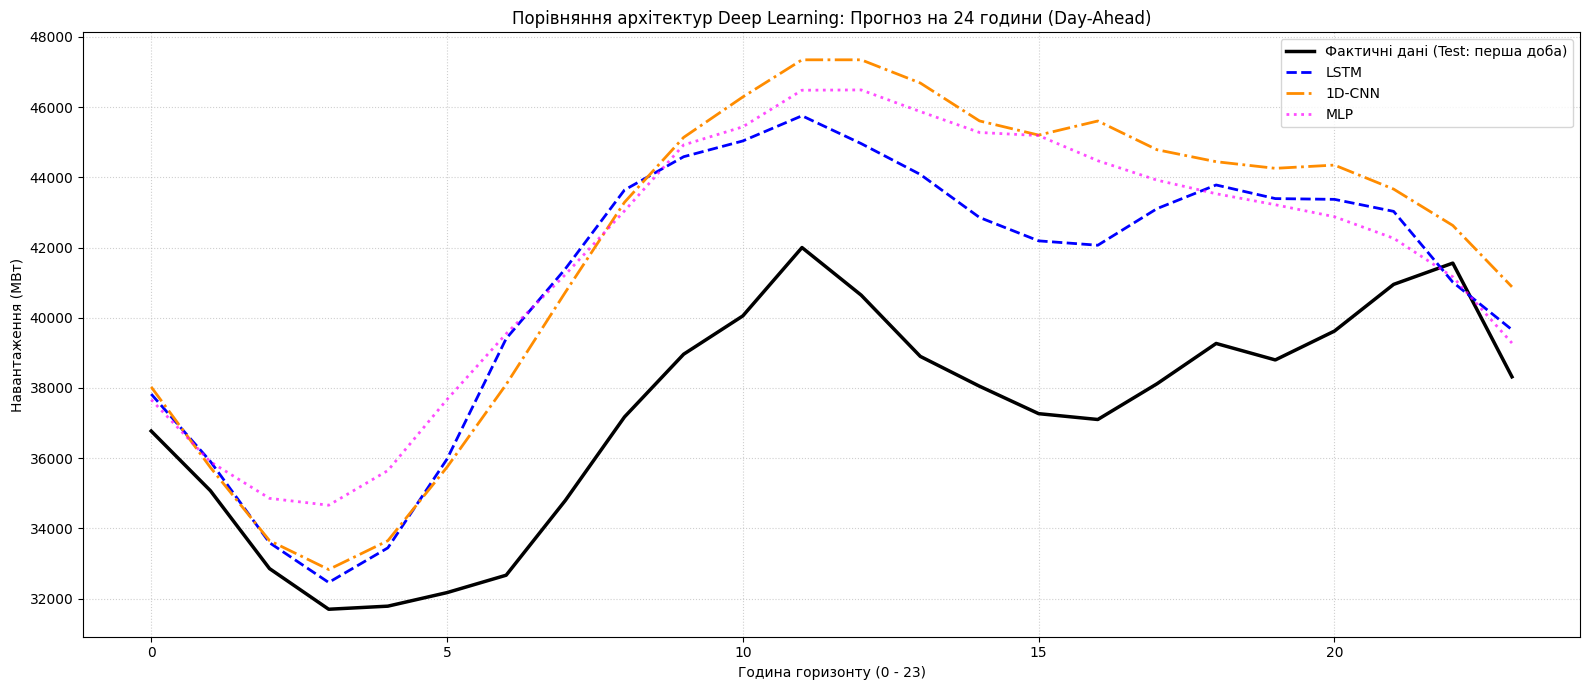

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1. Архітектура LSTM
def build_lstm_model(timesteps, features, output_dim):
    model = Sequential([
        Input(shape=(timesteps, features)),
        LSTM(units=64, activation='tanh', return_sequences=False),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(output_dim)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

timesteps = X_train_3d.shape[1]
features = X_train_3d.shape[2]
output_dimension = horizon

lstm_model = build_lstm_model(timesteps, features, output_dimension)
print(lstm_model.summary())

# 2. Навчання LSTM з власним екземпляром early stopping
print("\nПочаток навчання моделі LSTM. Це може зайняти трохи більше часу...")
es_lstm = make_early_stopping()

history_lstm = lstm_model.fit(
    X_train_3d,
    y_train_24h,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=[es_lstm],
    verbose=1
)

# 3. Оцінка моделі LSTM
print("\nГенерація прогнозів LSTM на тестовій вибірці...")
lstm_pred_scaled = lstm_model.predict(X_test_3d)
lstm_pred_unscaled = scaler_y.inverse_transform(lstm_pred_scaled)

mae_lstm = mean_absolute_error(y_test_true_unscaled, lstm_pred_unscaled)
rmse_lstm = np.sqrt(mean_squared_error(y_test_true_unscaled, lstm_pred_unscaled))

mask = y_test_true_unscaled != 0
mape_lstm = np.mean(np.abs(
    (y_test_true_unscaled[mask] - lstm_pred_unscaled[mask]) / y_test_true_unscaled[mask]
)) * 100

print("\n--- Результати LSTM (на горизонті 24 години) ---")
print(f"MAE:  {mae_lstm:.2f} МВт")
print(f"RMSE: {rmse_lstm:.2f} МВт")
print(f"MAPE: {mape_lstm:.2f}%")

# 4. Спільна візуалізація всіх 3 нейромереж
first_24h_true = y_test_true_unscaled[0]
first_24h_pred_lstm = lstm_pred_unscaled[0]
first_24h_pred_cnn = cnn_pred_unscaled[0]
first_24h_pred_mlp = mlp_pred_unscaled[0]

plt.figure(figsize=(16, 7))
plt.plot(range(24), first_24h_true, label='Фактичні дані (Test: перша доба)', color='black', linewidth=2.5)
plt.plot(range(24), first_24h_pred_lstm, label='LSTM', color='blue', linestyle='--', linewidth=2)
plt.plot(range(24), first_24h_pred_cnn, label='1D-CNN', color='darkorange', linestyle='-.', linewidth=2)
plt.plot(range(24), first_24h_pred_mlp, label='MLP', color='magenta', linestyle=':', linewidth=2, alpha=0.7)

plt.title('Порівняння архітектур Deep Learning: Прогноз на 24 години (Day-Ahead)')
plt.xlabel('Година горизонту (0 - 23)')
plt.ylabel('Навантаження (МВт)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### 4.4. XGBoost (Градієнтний бустинг)

Ініціалізація та навчання XGBoost (MultiOutput)...
Навчання завершено за 123.38 секунд.
Генерація прогнозів XGBoost на тестовій вибірці...

--- Результати XGBoost (на горизонті 24 години) ---
MAE:  1299.92 МВт
RMSE: 2046.23 МВт
MAPE: 2.42%


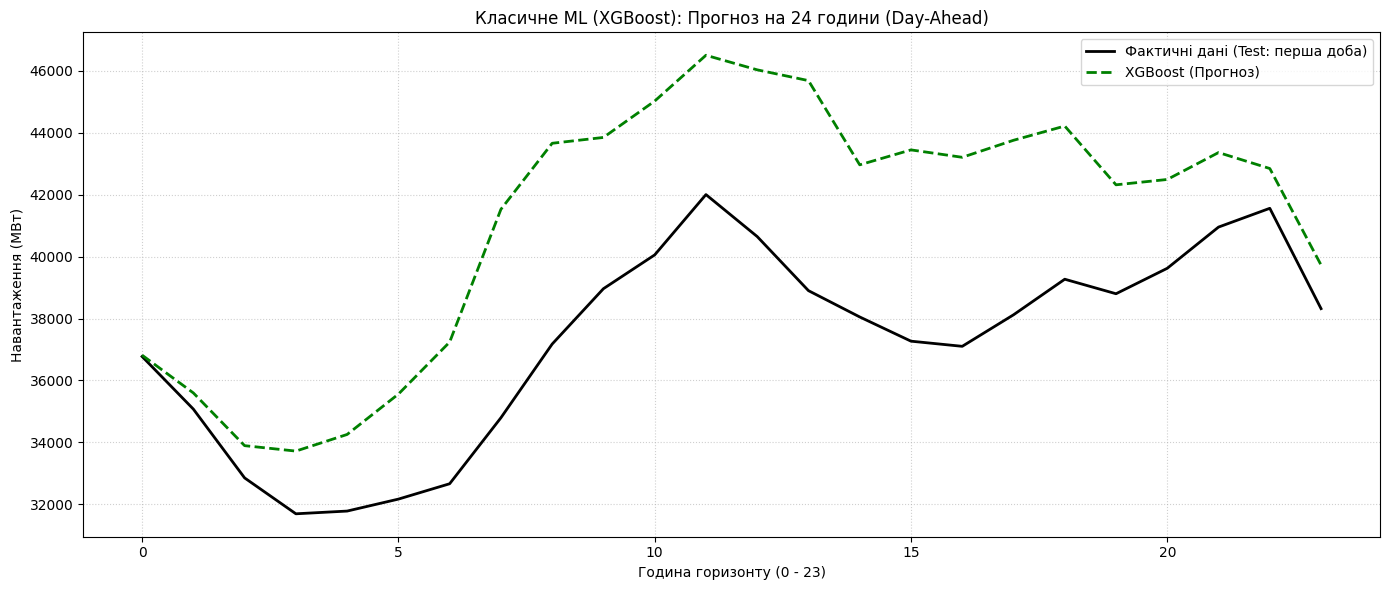

In [54]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import time

print("Ініціалізація та навчання XGBoost (MultiOutput)...")
start_time = time.time()

# 1. Базова модель XGBoost
base_xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

# 2. Обгортка для багатокрокового прогнозу (24 години)
multi_xgb = MultiOutputRegressor(base_xgb)

# 3. Навчання
multi_xgb.fit(X_train_2d, y_train_24h)

print(f"Навчання завершено за {time.time() - start_time:.2f} секунд.")
print("Генерація прогнозів XGBoost на тестовій вибірці...")

# 4. Прогноз та зворотне перетворення
xgb_pred_scaled = multi_xgb.predict(X_test_2d)
xgb_pred_unscaled = scaler_y.inverse_transform(xgb_pred_scaled)

# 5. Розрахунок метрик
mae_xgb = mean_absolute_error(y_test_true_unscaled, xgb_pred_unscaled)
rmse_xgb = np.sqrt(mean_squared_error(y_test_true_unscaled, xgb_pred_unscaled))

mask = y_test_true_unscaled != 0
mape_xgb = np.mean(np.abs(
    (y_test_true_unscaled[mask] - xgb_pred_unscaled[mask]) / y_test_true_unscaled[mask]
)) * 100

print("\n--- Результати XGBoost (на горизонті 24 години) ---")
print(f"MAE:  {mae_xgb:.2f} МВт")
print(f"RMSE: {rmse_xgb:.2f} МВт")
print(f"MAPE: {mape_xgb:.2f}%")

# 6. Візуалізація першої доби
first_24h_true = y_test_true_unscaled[0]
first_24h_pred_xgb = xgb_pred_unscaled[0]

plt.figure(figsize=(14, 6))
plt.plot(range(24), first_24h_true, label='Фактичні дані (Test: перша доба)', color='black', linewidth=2)
plt.plot(range(24), first_24h_pred_xgb, label='XGBoost (Прогноз)', color='green', linestyle='--', linewidth=2)

plt.title('Класичне ML (XGBoost): Прогноз на 24 години (Day-Ahead)')
plt.xlabel('Година горизонту (0 - 23)')
plt.ylabel('Навантаження (МВт)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### 4.5. Holt-Winters (Експоненційне згладжування)

Навчання класичної статистичної моделі (Holt-Winters)...
Навчання завершено за 0.64 секунд.

--- Результати Holt-Winters (лише перша доба тесту) ---
MAE:  956.73 МВт
RMSE: 1139.26 МВт
MAPE: 2.31%


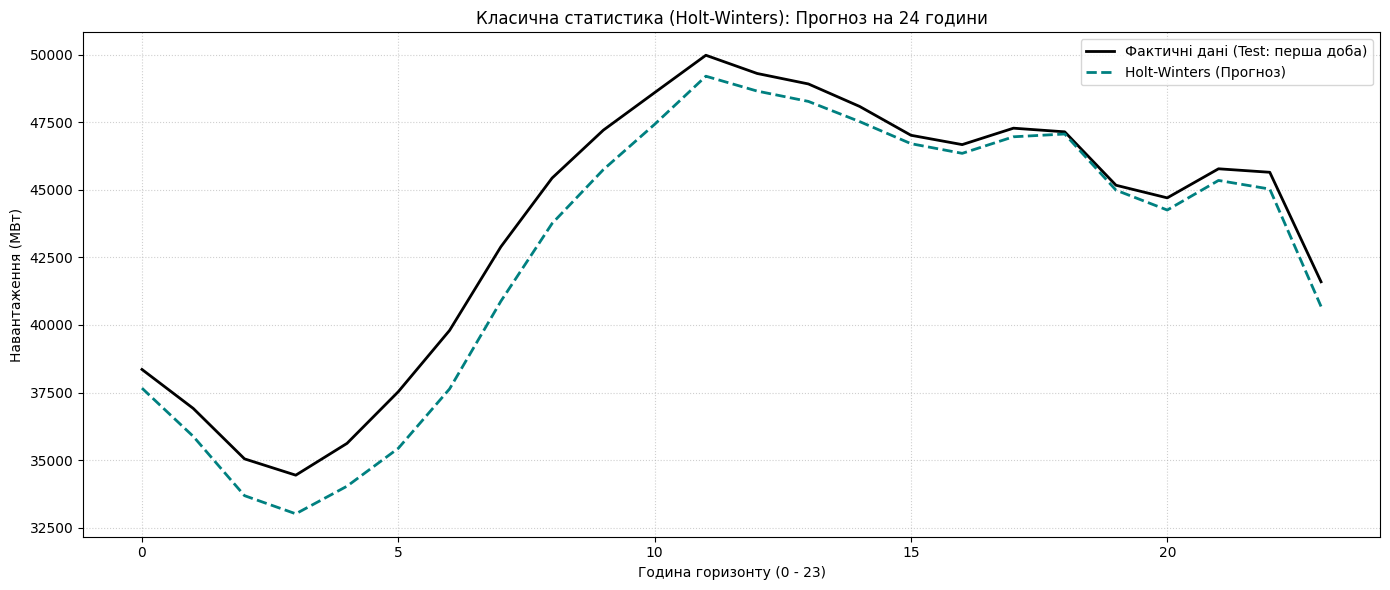

In [55]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import time

# Увага: ця клітинка — ілюстративний тест на першій добі тесту.
# Чесний розрахунок по всіх 139 вікнах виконується у наступній клітинці.

print("Навчання класичної статистичної моделі (Holt-Winters)...")
start_time = time.time()

train_series = train_df['actual_load'].values
test_series_24h = test_df['actual_load'].iloc[:24].values

hw_model = ExponentialSmoothing(
    train_series,
    trend=None,
    seasonal='add',
    seasonal_periods=24,
    initialization_method="estimated"
).fit()

print(f"Навчання завершено за {time.time() - start_time:.2f} секунд.")

# Прогноз на 24 години вперед
hw_pred_24h = hw_model.forecast(24)

# Розрахунок метрик
mae_hw = mean_absolute_error(test_series_24h, hw_pred_24h)
rmse_hw = np.sqrt(mean_squared_error(test_series_24h, hw_pred_24h))

mask = test_series_24h != 0
mape_hw = np.mean(np.abs(
    (test_series_24h[mask] - hw_pred_24h[mask]) / test_series_24h[mask]
)) * 100

print("\n--- Результати Holt-Winters (лише перша доба тесту) ---")
print(f"MAE:  {mae_hw:.2f} МВт")
print(f"RMSE: {rmse_hw:.2f} МВт")
print(f"MAPE: {mape_hw:.2f}%")

# Візуалізація
plt.figure(figsize=(14, 6))
plt.plot(range(24), test_series_24h, label='Фактичні дані (Test: перша доба)', color='black', linewidth=2)
plt.plot(range(24), hw_pred_24h, label='Holt-Winters (Прогноз)', color='teal', linestyle='--', linewidth=2)

plt.title('Класична статистика (Holt-Winters): Прогноз на 24 години')
plt.xlabel('Година горизонту (0 - 23)')
plt.ylabel('Навантаження (МВт)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [56]:
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error
import time
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter('ignore', ConvergenceWarning)

print("Чесний розрахунок Holt-Winters на тестовій вибірці (через ковзне вікно)...")
print("Це займе близько 1-2 хвилин, оскільки модель перенавчається для кожного вікна.\n")

step = 24
indices_to_test = range(0, len(X_test_3d), step)

hw_maes = []
hw_mapes = []

start_time = time.time()

for idx, i in enumerate(indices_to_test):
    # 1. Витягуємо та розмасштовуємо історію (168 год) для поточного вікна
    history_scaled = X_test_3d[i, :, 0].reshape(-1, 1)
    history_unscaled = scaler_y.inverse_transform(history_scaled).flatten()

    # 2. Фактичні дані на 24 години вперед
    true_24h = y_test_true_unscaled[i]

    # 3. Навчання Holt-Winters на поточному вікні
    hw_model = ExponentialSmoothing(
        history_unscaled,
        trend=None,
        seasonal='add',
        seasonal_periods=24,
        initialization_method="estimated"
    ).fit(optimized=True)

    # 4. Прогноз на 24 години
    pred_24h = hw_model.forecast(24)

    # 5. Метрики з захистом від ділення на нуль
    mae = mean_absolute_error(true_24h, pred_24h)
    mask = true_24h != 0
    mape = np.mean(np.abs((true_24h[mask] - pred_24h[mask]) / true_24h[mask])) * 100

    hw_maes.append(mae)
    hw_mapes.append(mape)

    if (idx + 1) % 50 == 0:
        print(f"Оброблено {idx + 1} з {len(indices_to_test)} добових вікон...")

print(f"\nРозрахунок завершено за {time.time() - start_time:.2f} секунд.")
print(f"--- Усереднений Holt-Winters (на {len(indices_to_test)} добових вікнах) ---")
print(f"Середній MAE:  {np.mean(hw_maes):.2f} МВт")
print(f"Середній MAPE: {np.mean(hw_mapes):.2f}%")

Чесний розрахунок Holt-Winters на тестовій вибірці (через ковзне вікно)...
Це займе близько 1-2 хвилин, оскільки модель перенавчається для кожного вікна.

Оброблено 50 з 139 добових вікон...
Оброблено 100 з 139 добових вікон...

Розрахунок завершено за 29.28 секунд.
--- Усереднений Holt-Winters (на 139 добових вікнах) ---
Середній MAE:  2511.70 МВт
Середній MAPE: 4.91%


### 4.6. SARIMAX

Підготовка даних та навчання SARIMAX. Будь ласка, зачекайте...
Навчання SARIMAX завершено за 3.38 секунд.

--- Результати SARIMAX (лише перша доба тесту) ---
MAE:  622.30 МВт
RMSE: 896.84 МВт
MAPE: 1.47%


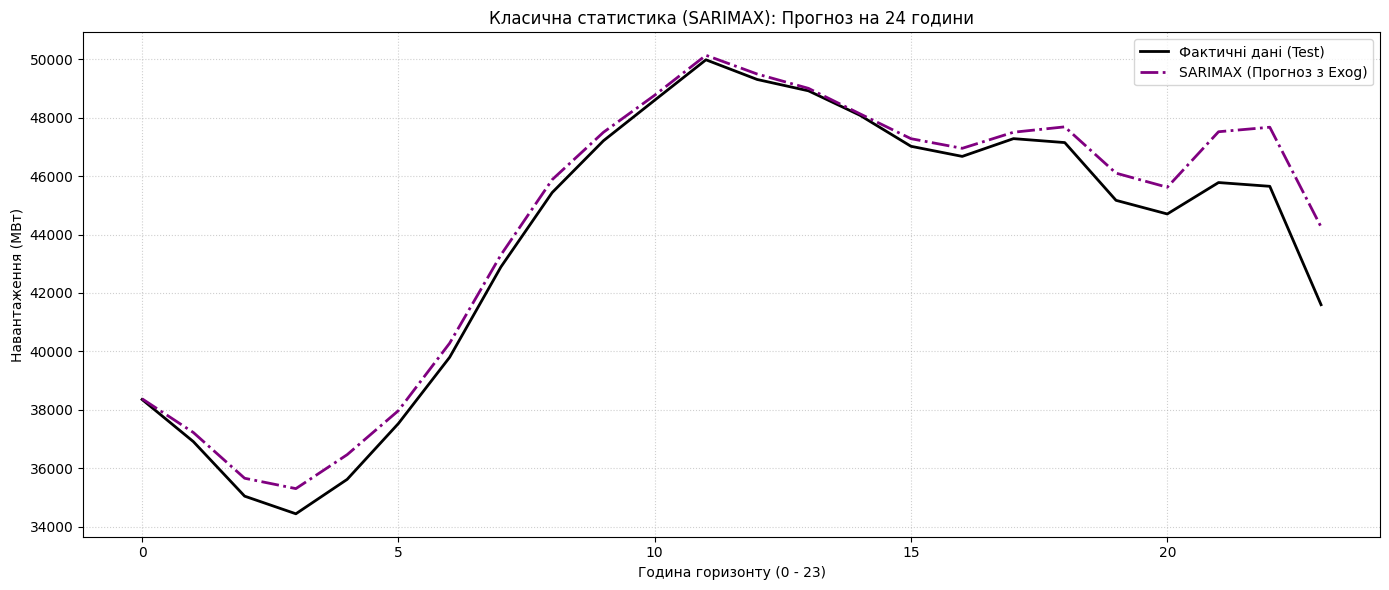

In [57]:
import statsmodels.api as sm
import numpy as np
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Увага: ця клітинка — ілюстративний тест лише на першій добі тесту.
# Чесний розрахунок по всіх 139 вікнах виконується у наступній клітинці.

print("Підготовка даних та навчання SARIMAX. Будь ласка, зачекайте...")
start_time = time.time()

history_len = 504

y_train_sarima = train_df['actual_load'].iloc[-history_len:]
X_train_sarima = train_df[['hour', 'dayofweek', 'is_weekend', 'month']].iloc[-history_len:]

y_test_sarima = test_df['actual_load'].iloc[:24]
X_test_sarima = test_df[['hour', 'dayofweek', 'is_weekend', 'month']].iloc[:24]

sarimax_model = sm.tsa.SARIMAX(
    endog=y_train_sarima,
    exog=X_train_sarima,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_results = sarimax_model.fit(disp=False)
print(f"Навчання SARIMAX завершено за {time.time() - start_time:.2f} секунд.")

sarimax_pred_24h = sarimax_results.forecast(steps=24, exog=X_test_sarima)

# Розрахунок метрик
mae_sarima = mean_absolute_error(y_test_sarima, sarimax_pred_24h)
rmse_sarima = np.sqrt(mean_squared_error(y_test_sarima, sarimax_pred_24h))

mask = y_test_sarima.values != 0
mape_sarima = np.mean(np.abs(
    (y_test_sarima.values[mask] - sarimax_pred_24h.values[mask]) / y_test_sarima.values[mask]
)) * 100

print("\n--- Результати SARIMAX (лише перша доба тесту) ---")
print(f"MAE:  {mae_sarima:.2f} МВт")
print(f"RMSE: {rmse_sarima:.2f} МВт")
print(f"MAPE: {mape_sarima:.2f}%")

# Візуалізація
plt.figure(figsize=(14, 6))
plt.plot(range(24), y_test_sarima.values, label='Фактичні дані (Test)', color='black', linewidth=2)
plt.plot(range(24), sarimax_pred_24h.values, label='SARIMAX (Прогноз з Exog)', color='purple', linestyle='-.', linewidth=2)

plt.title('Класична статистика (SARIMAX): Прогноз на 24 години')
plt.xlabel('Година горизонту (0 - 23)')
plt.ylabel('Навантаження (МВт)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [58]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error
import time
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter('ignore', ConvergenceWarning)

print("Чесний розрахунок SARIMAX на тестовій вибірці (крок 24 години)...")

# Об'єднуємо датасети для ковзного вікна
full_df = pd.concat([train_df, test_df])
test_start_idx = len(train_df)

history_len = 504
step = 24

# Використовуємо той самий діапазон що і в HW та фінальному бенчмарку
indices_to_test = range(0, len(X_test_3d), step)

sarima_maes = []
sarima_mapes = []

start_time = time.time()

for idx, i in enumerate(indices_to_test):
    current_idx = test_start_idx + i

    # 1. Історія для навчання (504 год перед поточним днем)
    y_train_roll = full_df['actual_load'].iloc[current_idx - history_len : current_idx]
    X_train_roll = full_df[['hour', 'dayofweek', 'is_weekend', 'month']].iloc[current_idx - history_len : current_idx]

    # 2. Фактичні дані на наступні 24 години
    y_test_roll = full_df['actual_load'].iloc[current_idx : current_idx + step]
    X_test_roll = full_df[['hour', 'dayofweek', 'is_weekend', 'month']].iloc[current_idx : current_idx + step]

    # 3. Навчання SARIMAX
    model = sm.tsa.SARIMAX(
        endog=y_train_roll,
        exog=X_train_roll,
        order=(1, 0, 1),
        seasonal_order=(1, 0, 1, 24),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    results = model.fit(disp=False)

    # 4. Прогноз на 24 години
    pred_24h = results.forecast(steps=step, exog=X_test_roll)

    # 5. Метрики з захистом від ділення на нуль
    mae = mean_absolute_error(y_test_roll, pred_24h)
    mask = y_test_roll.values != 0
    mape = np.mean(np.abs(
        (y_test_roll.values[mask] - pred_24h.values[mask]) / y_test_roll.values[mask]
    )) * 100

    sarima_maes.append(mae)
    sarima_mapes.append(mape)

    if (idx + 1) % 20 == 0:
        elapsed = time.time() - start_time
        print(f"Оброблено {idx + 1} з {len(indices_to_test)} вікон... (Минуло {elapsed:.1f} сек)")

total_time = time.time() - start_time
print(f"\nРозрахунок завершено за {total_time:.2f} секунд.")
print(f"--- Усереднений SARIMAX (на {len(indices_to_test)} добових вікнах) ---")
print(f"Середній MAE:  {np.mean(sarima_maes):.2f} МВт")
print(f"Середній MAPE: {np.mean(sarima_mapes):.2f}%")

Чесний розрахунок SARIMAX на тестовій вибірці (крок 24 години)...
Оброблено 20 з 139 вікон... (Минуло 66.1 сек)
Оброблено 40 з 139 вікон... (Минуло 127.7 сек)
Оброблено 60 з 139 вікон... (Минуло 191.4 сек)
Оброблено 80 з 139 вікон... (Минуло 254.1 сек)
Оброблено 100 з 139 вікон... (Минуло 316.7 сек)
Оброблено 120 з 139 вікон... (Минуло 373.3 сек)

Розрахунок завершено за 432.48 секунд.
--- Усереднений SARIMAX (на 139 добових вікнах) ---
Середній MAE:  2730.94 МВт
Середній MAPE: 5.35%


## 5. Фінальний зведений бенчмарк

In [59]:
import numpy as np
import pandas as pd

print("--- ФІНАЛЬНИЙ ЧЕСНИЙ БЕНЧМАРК (ОДНАКОВІ УМОВИ ДЛЯ ВСІХ) ---")
print(f"Оцінка проводиться на {len(range(0, len(X_test_3d), 24))} незалежних добових вікнах (без перекриття).\n")

step = 24
indices = range(0, len(X_test_3d), step)

def calculate_fair_metrics(preds_all, name):
    preds_sliced = preds_all[indices]
    true_sliced = y_test_true_unscaled[indices]

    # Захист від ділення на нуль
    mask = true_sliced != 0
    mae = np.mean(np.abs(true_sliced[mask] - preds_sliced[mask]))
    mape = np.mean(np.abs(
        (true_sliced[mask] - preds_sliced[mask]) / true_sliced[mask]
    )) * 100
    return mape, mae

results = []

# 1. Базові моделі
mape, mae = calculate_fair_metrics(daily_pred_unscaled, "Daily Seasonal Naïve")
results.append({"Модель": "Daily Seasonal Naïve", "Клас": "Baseline", "MAPE (%)": round(mape, 2), "MAE (МВт)": round(mae, 2)})

mape, mae = calculate_fair_metrics(weekly_pred_unscaled, "Weekly Seasonal Naïve")
results.append({"Модель": "Weekly Seasonal Naïve", "Клас": "Baseline", "MAPE (%)": round(mape, 2), "MAE (МВт)": round(mae, 2)})

# 2. Нейромережі
mape, mae = calculate_fair_metrics(mlp_pred_unscaled, "MLP")
results.append({"Модель": "MLP", "Клас": "Deep Learning", "MAPE (%)": round(mape, 2), "MAE (МВт)": round(mae, 2)})

mape, mae = calculate_fair_metrics(cnn_pred_unscaled, "1D-CNN")
results.append({"Модель": "1D-CNN", "Клас": "Deep Learning", "MAPE (%)": round(mape, 2), "MAE (МВт)": round(mae, 2)})

mape, mae = calculate_fair_metrics(lstm_pred_unscaled, "LSTM")
results.append({"Модель": "LSTM", "Клас": "Deep Learning", "MAPE (%)": round(mape, 2), "MAE (МВт)": round(mae, 2)})

# 3. XGBoost
mape, mae = calculate_fair_metrics(xgb_pred_unscaled, "XGBoost")
results.append({"Модель": "XGBoost", "Клас": "Traditional ML", "MAPE (%)": round(mape, 2), "MAE (МВт)": round(mae, 2)})

# 4. Класична статистика — використовуємо реально розраховані значення з Cell 14 і 16
results.append({
    "Модель": "Holt-Winters",
    "Клас": "Classic Statistics",
    "MAPE (%)": round(np.mean(hw_mapes), 2),
    "MAE (МВт)": round(np.mean(hw_maes), 2)
})
results.append({
    "Модель": "SARIMAX",
    "Клас": "Classic Statistics",
    "MAPE (%)": round(np.mean(sarima_mapes), 2),
    "MAE (МВт)": round(np.mean(sarima_maes), 2)
})

# Сортуємо від найкращої до найгіршої за MAPE
results_df = pd.DataFrame(results).sort_values(by="MAPE (%)").reset_index(drop=True)
results_df.index = results_df.index + 1

print(results_df.to_string())

--- ФІНАЛЬНИЙ ЧЕСНИЙ БЕНЧМАРК (ОДНАКОВІ УМОВИ ДЛЯ ВСІХ) ---
Оцінка проводиться на 139 незалежних добових вікнах (без перекриття).

                  Модель                Клас  MAPE (%)  MAE (МВт)
1                XGBoost      Traditional ML      2.42    1309.73
2                   LSTM       Deep Learning      3.02    1625.27
3                 1D-CNN       Deep Learning      3.87    2084.03
4                    MLP       Deep Learning      4.26    2266.33
5           Holt-Winters  Classic Statistics      4.91    2511.70
6                SARIMAX  Classic Statistics      5.35    2730.94
7   Daily Seasonal Naïve            Baseline      5.54    2871.92
8  Weekly Seasonal Naïve            Baseline      6.30    3545.94
